# Mortalidade infantil: quando a criança morre, e o que isso denuncia

**A pergunta:** a taxa de mortalidade infantil é o indicador mais usado no
mundo para resumir a saúde de uma população — e o mais mal interpretado quando
desce ao nível municipal. Este notebook calcula a taxa corretamente, separa o
momento da morte (que aponta onde o cuidado falhou) e mostra por que a taxa de
um município pequeno é, quase sempre, ruído.

**Fonte:** cruzamento do SIM (óbitos) com o SINASC (nascidos vivos).

**Tempo estimado:** 6 a 10 minutos.

**O que você leva daqui:** o cálculo dos componentes neonatal e pós-neonatal,
a leitura do que cada um denuncia, e o tratamento do problema dos números
pequenos — o erro estatístico que mais aparece em relatórios municipais de
saúde.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


In [4]:
# ---- Uma armadilha do catálogo, e como escapar dela --------------------
# O parâmetro state= diz onde PROCURAR, e não filtra: a PySUS devolve o arquivo
# NACIONAL ao lado do arquivo do estado. Pior, para 2025 e 2026 ela devolve
# SÓ o nacional. Pegar o primeiro da lista entrega o Brasil inteiro rotulado
# como estado — era o que este notebook fazia, e a mortalidade saía três vezes
# menor do que é.
import os

from pysus import list_files


def arquivo_da_uf(arquivos, uf, prefixo):
    """Entre os arquivos devolvidos, o DO ESTADO. Falha alto se não houver."""
    do_estado = [str(a) for a in arquivos
                 if os.path.basename(str(a)).upper().startswith(
                     f"{prefixo}{uf}".upper())]
    if not do_estado:
        nacionais = [os.path.basename(str(a)) for a in arquivos]
        raise ValueError(
            f"Não existe arquivo de {uf} para este ano: a PySUS ofereceu só "
            f"{nacionais}, que é nacional. Use ano_com_arquivo_da_uf() para "
            "escolher um ano que tenha arquivo estadual.")
    return do_estado[0].replace("\\", "/")


def ano_com_arquivo_da_uf(base, uf, prefixo, ate=None):
    """O ano mais recente COM arquivo do estado — que é também um ano fechado.

    Anos em andamento (2025, 2026) só têm o arquivo nacional, e ainda por cima
    estão incompletos: contar óbitos neles subestima tudo.
    """
    catalogo = list_files(dataset=base, state=uf)
    anos = []
    for nome, ano in zip(catalogo["name"], catalogo["year"]):
        if ano != ano:            # NaN
            continue
        if os.path.basename(str(nome)).upper().startswith(f"{prefixo}{uf}".upper()):
            if ate is None or int(ano) <= int(ate):
                anos.append(int(ano))
    if not anos:
        raise ValueError(f"Nenhum ano de {base} tem arquivo de {uf}.")
    return max(anos)

def anos_com_arquivo_da_uf(base, uf, prefixo):
    """Todos os anos que têm arquivo DO ESTADO, em ordem.

    É deste conjunto que a série histórica tem de sair: anos que só existem no
    arquivo nacional entrariam com o número do Brasil inteiro.
    """
    catalogo = list_files(dataset=base, state=uf)
    anos = set()
    for nome, ano in zip(catalogo["name"], catalogo["year"]):
        if ano != ano:
            continue
        if os.path.basename(str(nome)).upper().startswith(f"{prefixo}{uf}".upper()):
            anos.add(int(ano))
    return sorted(anos)


## 1. O que você pode trocar

In [5]:
UF = "PR"
ANOS_SERIE = 8
MINIMO_NASCIMENTOS = 300   # abaixo disso, a taxa municipal não se sustenta

print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. Numerador e denominador vêm de bases diferentes

Aqui está o que faz deste um notebook de cruzamento: os óbitos infantis estão
no SIM e os nascidos vivos no SINASC. As duas bases são independentes, têm
prazos de fechamento diferentes e nem sempre cobrem os mesmos anos.

O primeiro passo, então, é descobrir em quais anos **as duas** existem.

In [6]:
from pysus import list_files, sim, sinasc

anos_sim = {int(a) for a in list_files(dataset="sim", state=UF)["year"].dropna()}
anos_sinasc = {int(a) for a in list_files(dataset="sinasc", state=UF)["year"].dropna()}
# So os anos com arquivo DO ESTADO nas duas bases: 2025 e 2026 existem
# apenas no arquivo nacional, e entrariam com o numero do Brasil.
com_estado_sim = set(anos_com_arquivo_da_uf("sim", UF, "DO"))
com_estado_nasc = set(anos_com_arquivo_da_uf("sinasc", UF, "DN"))
comuns = sorted(anos_sim & anos_sinasc & com_estado_sim & com_estado_nasc)

ANO = comuns[-1]
serie = [a for a in comuns if a > ANO - ANOS_SERIE]

print(f"SIM tem {len(anos_sim)} anos, até {max(anos_sim)}")
print(f"SINASC tem {len(anos_sinasc)} anos, até {max(anos_sinasc)}")
print(f"Anos com as duas bases: {len(comuns)}, até {ANO}")
print()
print(f"O SIM costuma estar mais adiantado que o SINASC. Usar o ano mais recente")
print(f"do SIM sem conferir o SINASC produz uma taxa com denominador ausente —")
print(f"ou, pior, com o denominador de outro ano.")
print()
print(f"Ano de referência: {ANO}   |   série: {serie[0]} a {serie[-1]}")

SIM tem 48 anos, até 2026
SINASC tem 33 anos, até 2026
Anos com as duas bases: 27, até 2022
O SIM costuma estar mais adiantado que o SINASC. Usar o ano mais recente
do SIM sem conferir o SINASC produz uma taxa com denominador ausente —
ou, pior, com o denominador de outro ano.
Ano de referência: 2022   |   série: 2015 a 2022


## 3. Quem entra na conta

Duas definições precisam ficar explícitas, porque delas depende tudo:

- **Óbito infantil** é a morte de nascido vivo antes de completar um ano. No
  SIM, isso significa código de idade com unidade menor que "anos" — minutos,
  horas, dias ou meses. Óbitos fetais (natimortos) **não entram**: eles estão
  no arquivo com `TIPOBITO = 1` e pertencem a outro indicador.
- **Nascido vivo** é o registro do SINASC, sem filtro adicional.

A taxa é o número de óbitos por **mil** nascidos vivos — não por cem mil, como
nas taxas de mortalidade geral.

In [7]:
def obitos_infantis(uf, ano):
    """Óbitos de menores de 1 ano, com dias de vida e causa básica.

    A idade no SIM é um código: o primeiro dígito é a unidade (0 minutos,
    1 horas, 2 dias, 3 meses, 4 anos) e os dois seguintes o valor.
    """
    caminho = arquivo_da_uf(sim(uf, ano), uf, "DO")
    return con.execute(f"""
        SELECT CAUSABAS, CODMUNRES, SEXO, PESO, IDADE, TIPOBITO,
               CASE substr(IDADE, 1, 1)
                 WHEN '0' THEN 0
                 WHEN '1' THEN 0
                 WHEN '2' THEN TRY_CAST(substr(IDADE, 2, 2) AS INTEGER)
                 WHEN '3' THEN TRY_CAST(substr(IDADE, 2, 2) AS INTEGER) * 30
               END AS dias_de_vida
        FROM read_parquet('{caminho}')
        WHERE TIPOBITO = '2'
          AND substr(IDADE, 1, 1) IN ('0', '1', '2', '3')
    """).df()

def nascidos_vivos(uf, ano):
    "Nascidos vivos, com município de residência e peso."
    caminho = arquivo_da_uf(sinasc(uf, ano), uf, "DN")
    return con.execute(f"""
        SELECT CODMUNRES, PESO, SEXO, GESTACAO
        FROM read_parquet('{caminho}')
    """).df()

obitos = obitos_infantis(UF, ANO)
nascimentos = nascidos_vivos(UF, ANO)

taxa = len(obitos) / len(nascimentos) * 1000

print(f"{UF}, {ANO}")
print(f"  óbitos de menores de 1 ano: {mil(len(obitos))}")
print(f"  nascidos vivos:             {mil(len(nascimentos))}")
print()
print(f"  TAXA DE MORTALIDADE INFANTIL: {taxa:.2f} por mil nascidos vivos")
print()
print("Referências: o Brasil está em torno de 13 por mil; os estados do Sul e")
print("Sudeste, entre 9 e 12; os do Norte e Nordeste, acima de 15. Países ricos")
print("ficam abaixo de 4.")

PR, 2022
  óbitos de menores de 1 ano: 1.451
  nascidos vivos:             140.637
  TAXA DE MORTALIDADE INFANTIL: 10.32 por mil nascidos vivos
Referências: o Brasil está em torno de 13 por mil; os estados do Sul e
Sudeste, entre 9 e 12; os do Norte e Nordeste, acima de 15. Países ricos
ficam abaixo de 4.


## 4. Quando a criança morre — e o que cada momento denuncia

Este é o coração do indicador. A mortalidade infantil se divide em três
períodos, e cada um aponta para um serviço diferente:

| Componente | Quando | O que denuncia |
|---|---|---|
| **Neonatal precoce** | 0 a 6 dias de vida | Pré-natal e assistência ao parto |
| **Neonatal tardio** | 7 a 27 dias | Cuidado ao recém-nascido, UTI neonatal |
| **Pós-neonatal** | 28 dias a 1 ano | Atenção primária, saneamento, nutrição |

Um estado onde a mortalidade é quase toda neonatal precoce tem um problema de
maternidade. Um estado com pós-neonatal alta tem um problema de atenção básica
e de condições de vida. A taxa total não distingue os dois.

In [8]:
def componentes(obitos, nascimentos):
    "Taxas neonatal precoce, tardia e pós-neonatal, por mil nascidos vivos."
    dias = obitos["dias_de_vida"]
    total = len(nascimentos)
    faixas = {
        "Neonatal precoce (0-6 dias)": (dias <= 6).sum(),
        "Neonatal tardio (7-27 dias)": ((dias >= 7) & (dias <= 27)).sum(),
        "Pós-neonatal (28-364 dias)": (dias >= 28).sum(),
    }
    tabela = pd.DataFrame({
        "Óbitos": pd.Series(faixas),
        "Taxa por mil": pd.Series({k: v / total * 1000 for k, v in faixas.items()}),
    })
    tabela["% do total"] = tabela["Óbitos"] / tabela["Óbitos"].sum() * 100
    return tabela.round(2)

quadro = componentes(obitos, nascimentos)
neonatal = quadro.iloc[:2]["Taxa por mil"].sum()

print(f"Mortalidade neonatal (até 27 dias): {neonatal:.2f} por mil")
print(f"Corresponde a {neonatal / taxa * 100:.0f}% da mortalidade infantil\n")
quadro

Mortalidade neonatal (até 27 dias): 7.09 por mil
Corresponde a 69% da mortalidade infantil


,Óbitos,Taxa por mil,% do total
Neonatal precoce (0-6 dias),709,5.04,48.86
Neonatal tardio (7-27 dias),289,2.05,19.92
Pós-neonatal (28-364 dias),453,3.22,31.22


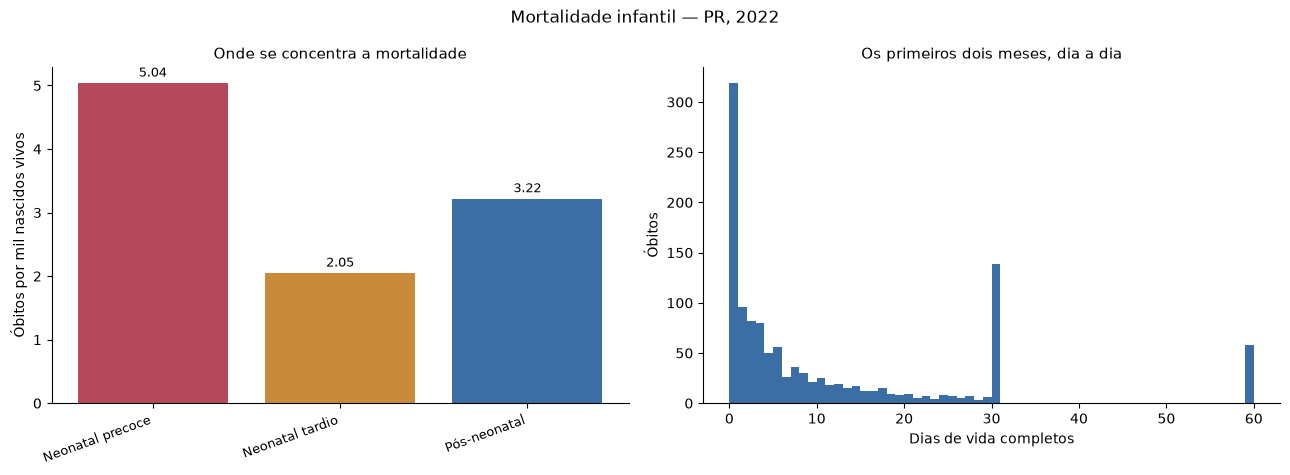

22% dos óbitos infantis acontecem no primeiro dia de vida.


In [9]:
figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 4.8))

cores = ["#b5495b", "#c98a3a", "#3b6ea5"]
eixo1.bar(range(len(quadro)), quadro["Taxa por mil"], color=cores)
eixo1.set_xticks(range(len(quadro)))
eixo1.set_xticklabels([i.split(" (")[0] for i in quadro.index],
                      rotation=20, ha="right", fontsize=9)
eixo1.set_ylabel("Óbitos por mil nascidos vivos")
eixo1.set_title("Onde se concentra a mortalidade", fontsize=11)
for indice, valor in enumerate(quadro["Taxa por mil"]):
    eixo1.text(indice, valor + 0.1, f"{valor:.2f}", ha="center", fontsize=9)

# distribuição dos dias de vida, para ver a concentração no primeiro dia
dias = obitos["dias_de_vida"].dropna()
eixo2.hist(dias[dias <= 60], bins=60, color="#3b6ea5")
eixo2.set_xlabel("Dias de vida completos")
eixo2.set_ylabel("Óbitos")
eixo2.set_title("Os primeiros dois meses, dia a dia", fontsize=11)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Mortalidade infantil — {UF}, {ANO}", fontsize=12)
plt.tight_layout()
plt.show()

primeiro_dia = (dias == 0).sum() / len(dias) * 100
print(f"{primeiro_dia:.0f}% dos óbitos infantis acontecem no primeiro dia de vida.")

A concentração no primeiro dia é a informação mais dura do gráfico. Ela não
descreve doenças de bebê: descreve prematuridade extrema, complicações do
parto e malformações incompatíveis com a vida. É por isso que a mortalidade
infantil brasileira parou de cair no ritmo antigo — o que restou a reduzir
está quase todo nas primeiras 24 horas, e depende da qualidade da assistência
obstétrica e neonatal, não de saneamento ou vacina.

## 5. De que morrem

Duas causas dominam e vale distingui-las, porque uma é evitável e a outra
quase não é.

In [10]:
GRUPOS = {
    "P": "Afecções perinatais (prematuridade, asfixia, infecção neonatal)",
    "Q": "Malformações congênitas",
    "A": "Infecciosas", "B": "Infecciosas",
    "J": "Respiratórias",
    "R": "Mal definidas",
    "E": "Endócrinas e metabólicas",
    "G": "Sistema nervoso",
    "K": "Digestivo",
    "V": "Causas externas", "W": "Causas externas",
    "X": "Causas externas", "Y": "Causas externas",
}

obitos["grupo"] = obitos["CAUSABAS"].astype(str).str.strip().str[0].map(GRUPOS)
obitos["grupo"] = obitos["grupo"].fillna("Demais causas")

causas = (
    obitos["grupo"].value_counts().rename("Óbitos").to_frame()
    .assign(**{"% do total": lambda d: (d["Óbitos"] / d["Óbitos"].sum() * 100).round(1)})
)

mal_definidas = causas.loc["Mal definidas", "% do total"] if "Mal definidas" in causas.index else 0
print(f"Causas mal definidas: {mal_definidas}% "
      f"(acima de 10% compromete a análise)\n")
causas

Causas mal definidas: 2.3% (acima de 10% compromete a análise)


,Óbitos,% do total
grupo,,
"Afecções perinatais (prematuridade, asfixia, infecção neonatal)",800,55.1
Malformações congênitas,370,25.5
Causas externas,88,6.1
Infecciosas,53,3.7
Respiratórias,50,3.4
Mal definidas,33,2.3
Demais causas,31,2.1
Sistema nervoso,11,0.8
Endócrinas e metabólicas,8,0.6


Composição das causas em cada período (%)


dias_de_vida,0-6 dias,7-27 dias,28+ dias
grupo,,,
"Afecções perinatais (prematuridade, asfixia, infecção neonatal)",72.5,73.7,16.1
Malformações congênitas,25.5,21.5,28.0
Causas externas,0.3,1.4,18.1
Infecciosas,1.3,0.3,9.5
Respiratórias,0.0,1.0,10.4
Mal definidas,0.1,1.4,6.2


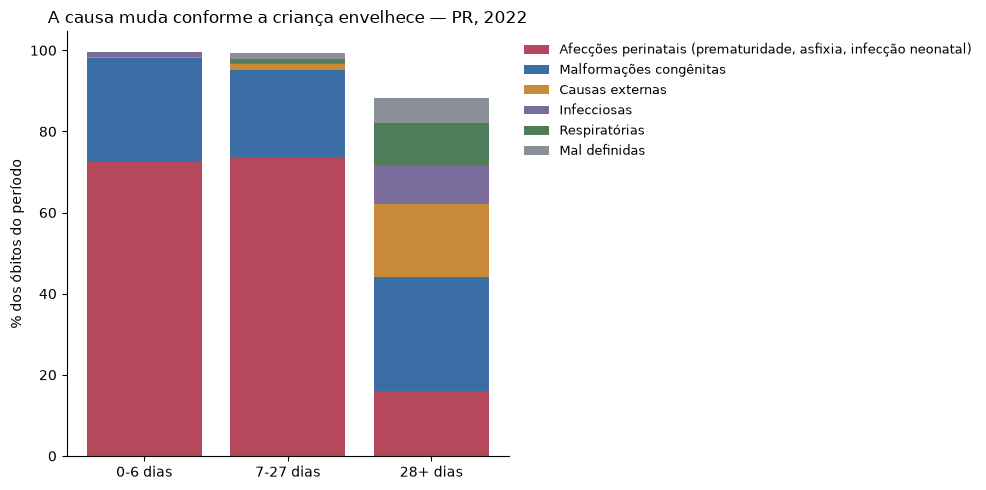

In [11]:
tabela_cruzada = pd.crosstab(
    obitos["grupo"],
    pd.cut(obitos["dias_de_vida"], [-1, 6, 27, 400],
           labels=["0-6 dias", "7-27 dias", "28+ dias"]),
    normalize="columns") * 100
tabela_cruzada = tabela_cruzada.round(1)
ordem = causas.index[:6]
tabela_cruzada = tabela_cruzada.reindex([i for i in ordem if i in tabela_cruzada.index])

print("Composição das causas em cada período (%)\n")
display(tabela_cruzada)

figura, eixo = plt.subplots(figsize=(10, 5))
acumulado = pd.Series(0.0, index=tabela_cruzada.columns)
paleta = ["#b5495b", "#3b6ea5", "#c98a3a", "#7a6c9b", "#4f7d5a", "#8a8f98"]

for (nome, linha), cor in zip(tabela_cruzada.iterrows(), paleta):
    eixo.bar(tabela_cruzada.columns, linha, bottom=acumulado, color=cor, label=nome)
    acumulado = acumulado + linha

eixo.set_ylabel("% dos óbitos do período")
eixo.set_title(f"A causa muda conforme a criança envelhece — {UF}, {ANO}", fontsize=12)
eixo.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

A troca de composição entre as colunas é o retrato de duas medicinas
diferentes. Nos primeiros dias, afecções perinatais e malformações — nascer
cedo demais, nascer com um problema grave. Depois dos 28 dias, as infecções
ganham espaço, e aí a resposta não está na maternidade: está na unidade básica,
no aleitamento, na vacina, na casa em que a criança vive.

## 6. A série no tempo

In [12]:
historico = []
for ano in serie:
    obitos_ano = obitos_infantis(UF, ano)
    nascimentos_ano = nascidos_vivos(UF, ano)
    dias = obitos_ano["dias_de_vida"]
    historico.append({
        "Ano": ano,
        "Nascidos vivos": len(nascimentos_ano),
        "Óbitos infantis": len(obitos_ano),
        "Taxa infantil": round(len(obitos_ano) / len(nascimentos_ano) * 1000, 2),
        "Neonatal": round((dias <= 27).sum() / len(nascimentos_ano) * 1000, 2),
        "Pós-neonatal": round((dias >= 28).sum() / len(nascimentos_ano) * 1000, 2),
    })

historico = pd.DataFrame(historico)
historico

,Ano,Nascidos vivos,Óbitos infantis,Taxa infantil,Neonatal,Pós-neonatal
0,2015,160947,1758,10.92,7.87,3.05
1,2016,155066,1629,10.51,7.35,3.15
2,2017,157701,1633,10.36,7.49,2.87
3,2018,156201,1613,10.33,7.55,2.77
4,2019,153469,1582,10.31,7.33,2.98
5,2020,146291,1360,9.30,6.77,2.52
6,2021,141976,1343,9.46,6.60,2.86
7,2022,140637,1451,10.32,7.10,3.22


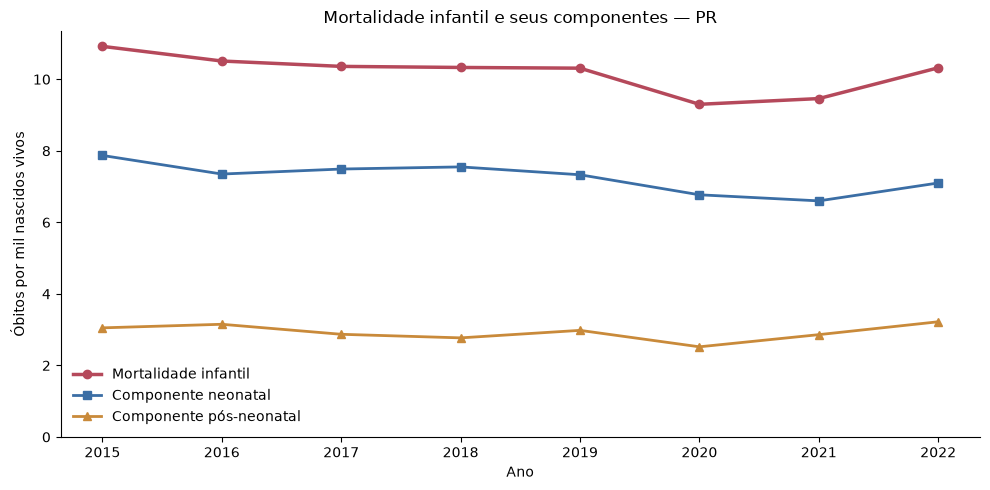

Variação de 2015 a 2022: -5.5%
A queda, quando há, vem quase toda do componente pós-neonatal — o
neonatal é o que resiste.


In [13]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot(historico["Ano"], historico["Taxa infantil"], marker="o",
          color="#b5495b", linewidth=2.5, label="Mortalidade infantil")
eixo.plot(historico["Ano"], historico["Neonatal"], marker="s",
          color="#3b6ea5", linewidth=2, label="Componente neonatal")
eixo.plot(historico["Ano"], historico["Pós-neonatal"], marker="^",
          color="#c98a3a", linewidth=2, label="Componente pós-neonatal")

eixo.set_ylabel("Óbitos por mil nascidos vivos")
eixo.set_xlabel("Ano")
eixo.set_title(f"Mortalidade infantil e seus componentes — {UF}", fontsize=12)
eixo.legend(frameon=False)
eixo.set_ylim(bottom=0)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

variacao = (historico["Taxa infantil"].iloc[-1] /
            historico["Taxa infantil"].iloc[0] - 1) * 100
print(f"Variação de {serie[0]} a {serie[-1]}: {variacao:+.1f}%")
print(f"A queda, quando há, vem quase toda do componente pós-neonatal — o")
print(f"neonatal é o que resiste.")

## 7. O problema dos números pequenos

Agora a parte que mais importa para quem trabalha em município.

Um município com 80 nascimentos por ano e **um** óbito infantil tem taxa de
12,5 por mil. Se no ano seguinte houver **dois**, a taxa "dobra" para 25. Nada
mudou na saúde daquela cidade: mudou uma criança. Ainda assim, é assim que
rankings municipais são publicados, e é assim que gestores são cobrados.

Vamos medir o tamanho do problema.

In [14]:
por_municipio = pd.DataFrame({
    "nascimentos": nascimentos["CODMUNRES"].astype(str).value_counts(),
    "obitos": obitos["CODMUNRES"].astype(str).value_counts(),
}).fillna(0)
por_municipio = por_municipio[por_municipio["nascimentos"] > 0]
por_municipio["taxa"] = (por_municipio["obitos"] /
                         por_municipio["nascimentos"] * 1000).round(1)

pequenos = por_municipio[por_municipio["nascimentos"] < MINIMO_NASCIMENTOS]
grandes = por_municipio[por_municipio["nascimentos"] >= MINIMO_NASCIMENTOS]

print(f"Municípios com nascimentos registrados: {len(por_municipio)}")
print(f"  com menos de {MINIMO_NASCIMENTOS} nascimentos: {len(pequenos)} "
      f"({len(pequenos) / len(por_municipio) * 100:.0f}%)")
print(f"  com {MINIMO_NASCIMENTOS} ou mais:              {len(grandes)}")
print()
print(f"Amplitude da taxa entre os pequenos: "
      f"{pequenos['taxa'].min():.1f} a {pequenos['taxa'].max():.1f} por mil")
print(f"Amplitude entre os grandes:          "
      f"{grandes['taxa'].min():.1f} a {grandes['taxa'].max():.1f} por mil")
print()
print(f"Municípios pequenos com taxa zero: {(pequenos['taxa'] == 0).sum()}")
print("Zero não significa excelência — significa que naquele ano não houve")
print("nenhum óbito, o que é o resultado mais provável quando nascem poucas")
print("crianças.")

Municípios com nascimentos registrados: 400
  com menos de 300 nascimentos: 320 (80%)
  com 300 ou mais:              80
Amplitude da taxa entre os pequenos: 0.0 a 97.6 por mil
Amplitude entre os grandes:          2.0 a 29.6 por mil
Municípios pequenos com taxa zero: 121
Zero não significa excelência — significa que naquele ano não houve
nenhum óbito, o que é o resultado mais provável quando nascem poucas
crianças.


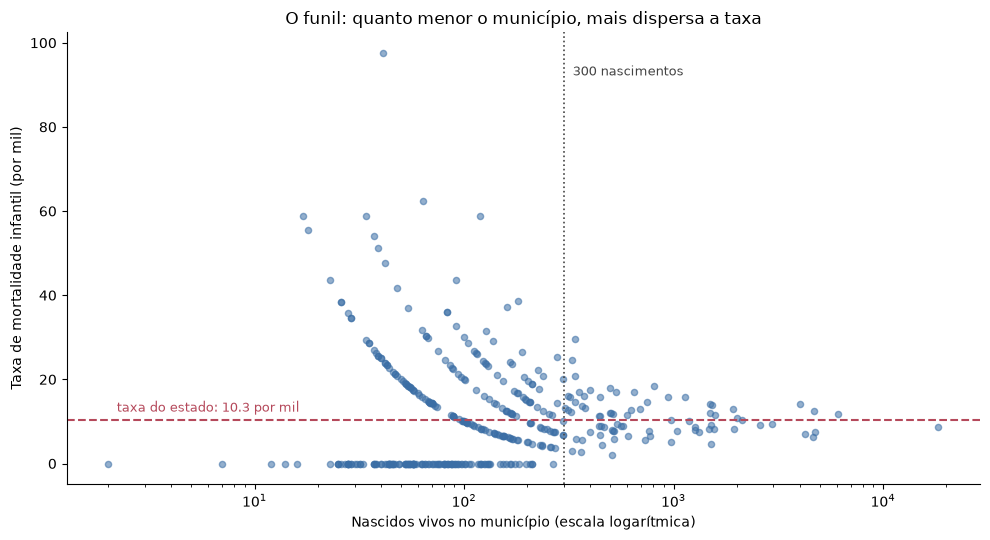

In [15]:
figura, eixo = plt.subplots(figsize=(10, 5.5))
eixo.scatter(por_municipio["nascimentos"], por_municipio["taxa"],
             s=20, alpha=0.55, color="#3b6ea5")
eixo.axhline(taxa, color="#b5495b", linestyle="--", linewidth=1.5)
eixo.axvline(MINIMO_NASCIMENTOS, color="#444", linestyle=":", linewidth=1.2)
eixo.set_xscale("log")

eixo.text(por_municipio["nascimentos"].min() * 1.1, taxa + 2,
          f"taxa do estado: {taxa:.1f} por mil", color="#b5495b", fontsize=9)
eixo.text(MINIMO_NASCIMENTOS * 1.1, eixo.get_ylim()[1] * 0.9,
          f"{MINIMO_NASCIMENTOS} nascimentos", color="#444", fontsize=9)

eixo.set_xlabel("Nascidos vivos no município (escala logarítmica)")
eixo.set_ylabel("Taxa de mortalidade infantil (por mil)")
eixo.set_title("O funil: quanto menor o município, mais dispersa a taxa",
               fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Esse formato de funil é a assinatura visual do problema. Não é desigualdade em
saúde — é aritmética. Onde nascem poucas crianças, a taxa oscila entre zero e
valores absurdos por acaso.

**A saída é somar anos.** Três anos de dados triplicam o denominador. É o que
fazem os sistemas oficiais quando publicam indicadores municipais — e o efeito
é menos óbvio do que parece, como a próxima tabela mostra.

In [16]:
anos_acumular = [a for a in comuns if a > ANO - 3]
acumulado_obitos, acumulado_nascimentos = [], []

for ano in anos_acumular:
    acumulado_obitos.append(obitos_infantis(UF, ano)["CODMUNRES"].astype(str))
    acumulado_nascimentos.append(nascidos_vivos(UF, ano)["CODMUNRES"].astype(str))

triênio = pd.DataFrame({
    "nascimentos": pd.concat(acumulado_nascimentos).value_counts(),
    "obitos": pd.concat(acumulado_obitos).value_counts(),
}).fillna(0)
triênio = triênio[triênio["nascimentos"] > 0]
triênio["taxa"] = (triênio["obitos"] / triênio["nascimentos"] * 1000).round(1)

def resumir(tabela, rotulo):
    "Indicadores de qualidade da estimativa municipal."
    suficientes = tabela[tabela["nascimentos"] >= MINIMO_NASCIMENTOS]
    return pd.Series({
        "Municípios com denominador suficiente": len(suficientes),
        "% dos municípios analisáveis": round(len(suficientes) / len(tabela) * 100, 1),
        "% da população de nascidos coberta": round(
            suficientes["nascimentos"].sum() / tabela["nascimentos"].sum() * 100, 1),
        "Municípios com taxa zero": int((tabela["taxa"] == 0).sum()),
        "Desvio-padrão entre os analisáveis": round(suficientes["taxa"].std(), 1),
        "Taxa máxima entre os analisáveis": round(suficientes["taxa"].max(), 1),
    }, name=rotulo)

comparacao = pd.concat([
    resumir(por_municipio, f"Um ano ({ANO})"),
    resumir(triênio, f"Três anos ({anos_acumular[0]}-{anos_acumular[-1]})"),
], axis=1)

print("O que muda ao acumular três anos\n")
display(comparacao)

print("\nOs dez municípios com maior taxa no triênio, "
      f"entre os que tiveram ao menos {MINIMO_NASCIMENTOS} nascimentos:")
triênio[triênio["nascimentos"] >= MINIMO_NASCIMENTOS].nlargest(10, "taxa")

O que muda ao acumular três anos


,Um ano (2022),Três anos (2020-2022)
Municípios com denominador suficiente,80.0,219.0
% dos municípios analisáveis,20.0,54.8
% da população de nascidos coberta,75.8,92.9
Municípios com taxa zero,121.0,51.0
Desvio-padrão entre os analisáveis,4.8,4.5
Taxa máxima entre os analisáveis,29.6,25.2


Os dez municípios com maior taxa no triênio, entre os que tiveram ao menos 300 nascimentos:


,nascimentos,obitos,taxa
CODMUNRES,,,
410750,397,10.0,25.2
411050,570,13.0,22.8
412385,395,9.0,22.8
412405,938,20.0,21.3
412000,336,7.0,20.8
412480,437,9.0,20.6
411705,536,11.0,20.5
412330,304,6.0,19.7
411250,410,8.0,19.5


Leia a tabela com cuidado, porque o ganho não é onde a intuição espera.

O desvio-padrão quase não muda, e a taxa máxima pode até subir. **O ganho é
quantos municípios passam a ter denominador suficiente para serem analisados**
— e, com eles, que fatia das crianças do estado deixa de ficar fora da conta.
Com um ano de dados, a maior parte dos municípios simplesmente não tem número
que sustente uma taxa. Com três, muitos entram.

E os "zeros" caem pela metade. Cada zero que desaparece era um município que
parecia ter mortalidade infantil nula e apenas não tivera óbito naquele ano.

É a segunda coluna que se pode levar a uma reunião — e, mesmo assim, só a parte
dela que passou no filtro do denominador.

## 8. Conferindo com a realidade

In [17]:
print("Verificações de sanidade\n")
print(f"1. Taxa infantil entre 5 e 25 por mil?         {taxa:.2f} "
      f"({'sim' if 5 < taxa < 25 else 'ATENÇÃO'})")
print(f"2. Neonatal é a maior parte (acima de 60%)?    "
      f"{neonatal / taxa * 100:.0f}% "
      f"({'sim' if neonatal / taxa > 0.6 else 'ATENÇÃO'})")
print(f"3. Afecções perinatais lideram as causas?      "
      f"{'sim' if causas.index[0].startswith('Afecções') else 'ATENÇÃO — ' + causas.index[0]}")
print(f"4. Causas mal definidas abaixo de 10%?         {mal_definidas}% "
      f"({'sim' if mal_definidas < 10 else 'ATENÇÃO'})")
print(f"5. Acumular anos ampliou o que dá para analisar? "
      f"{comparacao.iloc[0, 0]:.0f} para {comparacao.iloc[0, 1]:.0f} municípios "
      f"({'sim' if comparacao.iloc[0, 1] > comparacao.iloc[0, 0] else 'ATENÇÃO'})")

Verificações de sanidade
1. Taxa infantil entre 5 e 25 por mil?         10.32 (sim)
2. Neonatal é a maior parte (acima de 60%)?    69% (sim)
3. Afecções perinatais lideram as causas?      sim
4. Causas mal definidas abaixo de 10%?         2.3% (sim)
5. Acumular anos ampliou o que dá para analisar? 80 para 219 municípios (sim)


## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "PE"` |
| Mortalidade neonatal apenas | use a coluna `Neonatal` da série |
| Mortalidade fetal (natimortos) | troque o filtro para `TIPOBITO = '1'` — é outro indicador |
| Recorte por peso ao nascer | a coluna `PESO` está nas duas bases |
| Por raça/cor da mãe | acrescente `RACACORMAE` na consulta do SINASC |
| Regiões de saúde em vez de municípios | agrupe pelo código da região, como no notebook do CNES |
| Estabilizar ainda mais | acumule cinco anos em vez de três |

### O que vale levar

A separação entre **neonatal e pós-neonatal** — ela diz qual serviço precisa
de atenção, coisa que a taxa total nunca diz.

E a regra dos números pequenos: **antes de publicar taxa municipal, olhe o
denominador.** Se nascem poucas crianças, some anos. Um ranking de municípios
por taxa anual é, na maior parte, um ranking de acaso.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SIM e SINASC/DATASUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*